
# Phase 3 Project: Predicting Customer Churn for SyriaTel

**Author:** Ted Mutuma  
**Project Type:** Binary Classification  
**Primary Stakeholder:** Customer Retention Manager, SyriaTel

## Project Overview
SyriaTel loses revenue whenever customers leave the network. The goal of this project is to build a classification model that can identify customers who are at high risk of churn so the retention team can intervene early with targeted offers, service recovery, or outreach.

## Business Problem
SyriaTel wants to reduce customer churn by proactively identifying which customers are most likely to leave. A predictive model can help the company prioritize retention efforts and use limited retention resources more efficiently.

## Project Success Criteria
Because missing a true churner means losing a customer and the revenue attached to that account, **recall for the churn class** will be the primary metric. I will also report **precision, F1-score, accuracy, and ROC-AUC** to keep the evaluation balanced.

## Notebook Structure
This notebook follows the full data science workflow:
1. Business Understanding  
2. Data Understanding  
3. Data Preparation  
4. Modeling  
5. Evaluation  
6. Recommendations and Limitations


In [1]:

# Imports
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)


## 1. Data Understanding

In [2]:

# Load data
file_path = 'bigml_59c28831336c6604c800002a.csv'
df = pd.read_csv(file_path)

print(f"Dataset shape: {df.shape}")
df.head()


Dataset shape: (3333, 21)


,state,account length,area code,phone number,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,total eve minutes,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [3]:

# Basic structure
info_df = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'missing_values': df.isna().sum(),
    'n_unique': df.nunique()
}).sort_values(by='dtype')
info_df


,dtype,missing_values,n_unique
churn,bool,0,2
total intl charge,float64,0,162
total intl minutes,float64,0,162
total night charge,float64,0,933
total night minutes,float64,0,1591
total eve charge,float64,0,1440
total day charge,float64,0,1667
total eve minutes,float64,0,1611
total day minutes,float64,0,1667
total day calls,int64,0,119



### Initial observations
- The dataset contains **3,333 customer records** and **21 columns**.
- The target variable is **`churn`**, which is already a binary label.
- There are **no missing values** in this dataset, but I will still use imputers in the pipelines as a best-practice workflow.
- `phone number` appears to be a customer identifier rather than a meaningful predictor, so it should not be used for modeling.
- `state`, `international plan`, and `voice mail plan` are categorical and will need encoding.


In [4]:

# Descriptive statistics
num_summary = df.describe().T
num_summary


,count,mean,std,min,25%,50%,75%,max
account length,3333.0,101.064806,39.822106,1.00,74.00,101.00,127.00,243.00
area code,3333.0,437.182418,42.371290,408.00,408.00,415.00,510.00,510.00
number vmail messages,3333.0,8.099010,13.688365,0.00,0.00,0.00,20.00,51.00
total day minutes,3333.0,179.775098,54.467389,0.00,143.70,179.40,216.40,350.80
total day calls,3333.0,100.435644,20.069084,0.00,87.00,101.00,114.00,165.00
total day charge,3333.0,30.562307,9.259435,0.00,24.43,30.50,36.79,59.64
total eve minutes,3333.0,200.980348,50.713844,0.00,166.60,201.40,235.30,363.70
total eve calls,3333.0,100.114311,19.922625,0.00,87.00,100.00,114.00,170.00
total eve charge,3333.0,17.083540,4.310668,0.00,14.16,17.12,20.00,30.91
total night minutes,3333.0,200.872037,50.573847,23.20,167.00,201.20,235.30,395.00


In [5]:
# Check duplicates and target balance
print('Duplicate rows:', df.duplicated().sum())
print('\nTarget distribution:')
print(df['churn'].value_counts())
print('\nTarget proportions:')
print(df['churn'].value_counts(normalize=True).round(3))


Duplicate rows: 0

Target distribution:
churn
False    2850
True      483
Name: count, dtype: int64

Target proportions:
churn
False    0.855
True     0.145
Name: proportion, dtype: float64


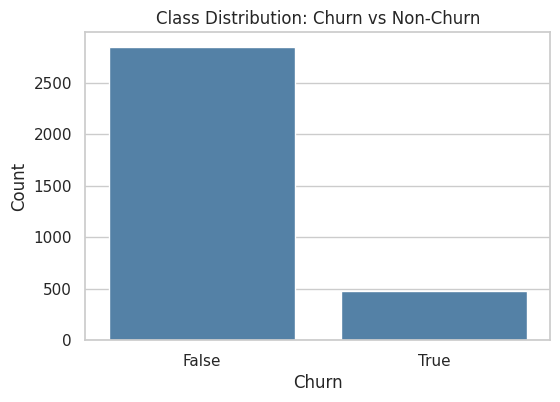

In [6]:
# Visualize class imbalance
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='churn', color='steelblue')
plt.title('Class Distribution: Churn vs Non-Churn')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.show()



The target is imbalanced: roughly **14.5%** of customers churn while **85.5%** do not. This means accuracy alone could be misleading. A model that predicts most customers as non-churners could still look good on accuracy while failing the business goal. That is why **recall for the churn class** is the primary metric.


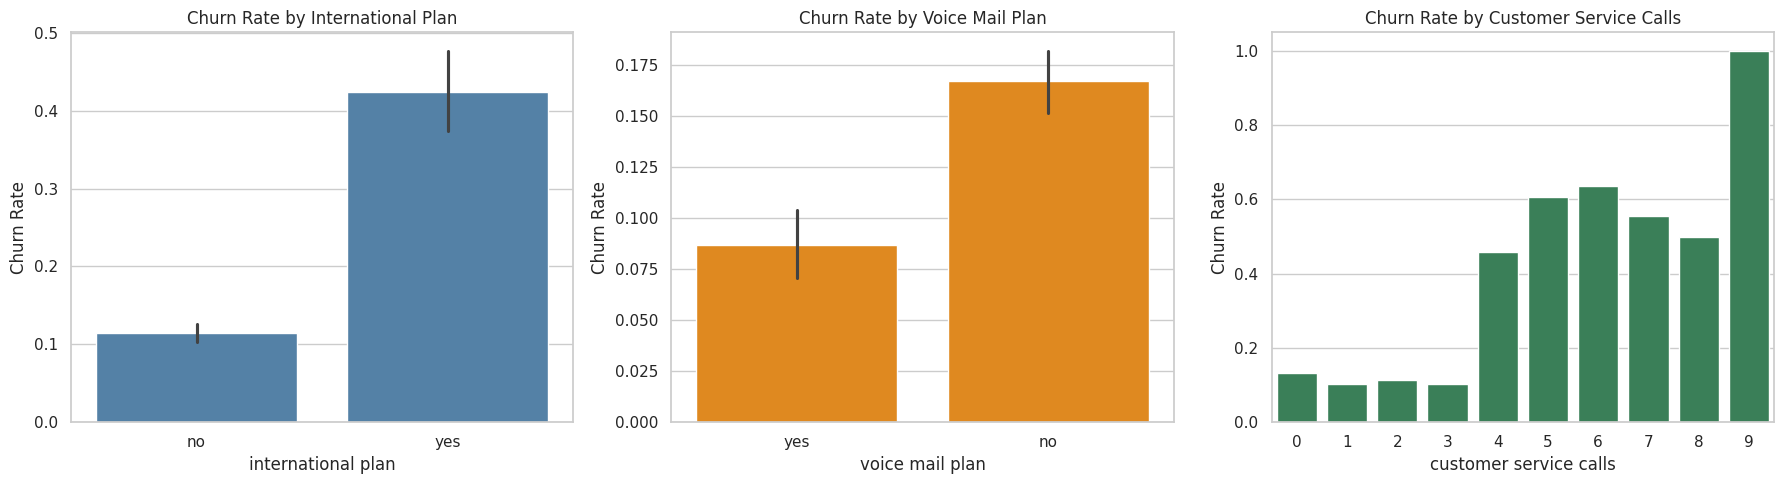

In [7]:
# Explore churn rate by selected business-relevant variables
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=df, x='international plan', y=df['churn'].astype(int), ax=axes[0], color='steelblue')
axes[0].set_title('Churn Rate by International Plan')
axes[0].set_ylabel('Churn Rate')

sns.barplot(data=df, x='voice mail plan', y=df['churn'].astype(int), ax=axes[1], color='darkorange')
axes[1].set_title('Churn Rate by Voice Mail Plan')
axes[1].set_ylabel('Churn Rate')

sns.barplot(data=df, x='customer service calls', y=df['churn'].astype(int), ax=axes[2], estimator=np.mean, errorbar=None, color='seagreen')
axes[2].set_title('Churn Rate by Customer Service Calls')
axes[2].set_ylabel('Churn Rate')

plt.tight_layout()
plt.show()


In [8]:

# Compare average usage patterns by churn
comparison = df.groupby('churn')[[
    'total day minutes', 'total eve minutes', 'total night minutes',
    'total intl minutes', 'customer service calls'
]].mean().round(2)
comparison


,total day minutes,total eve minutes,total night minutes,total intl minutes,customer service calls
churn,,,,,
False,175.18,199.04,200.13,10.16,1.45
True,206.91,212.41,205.23,10.70,2.23


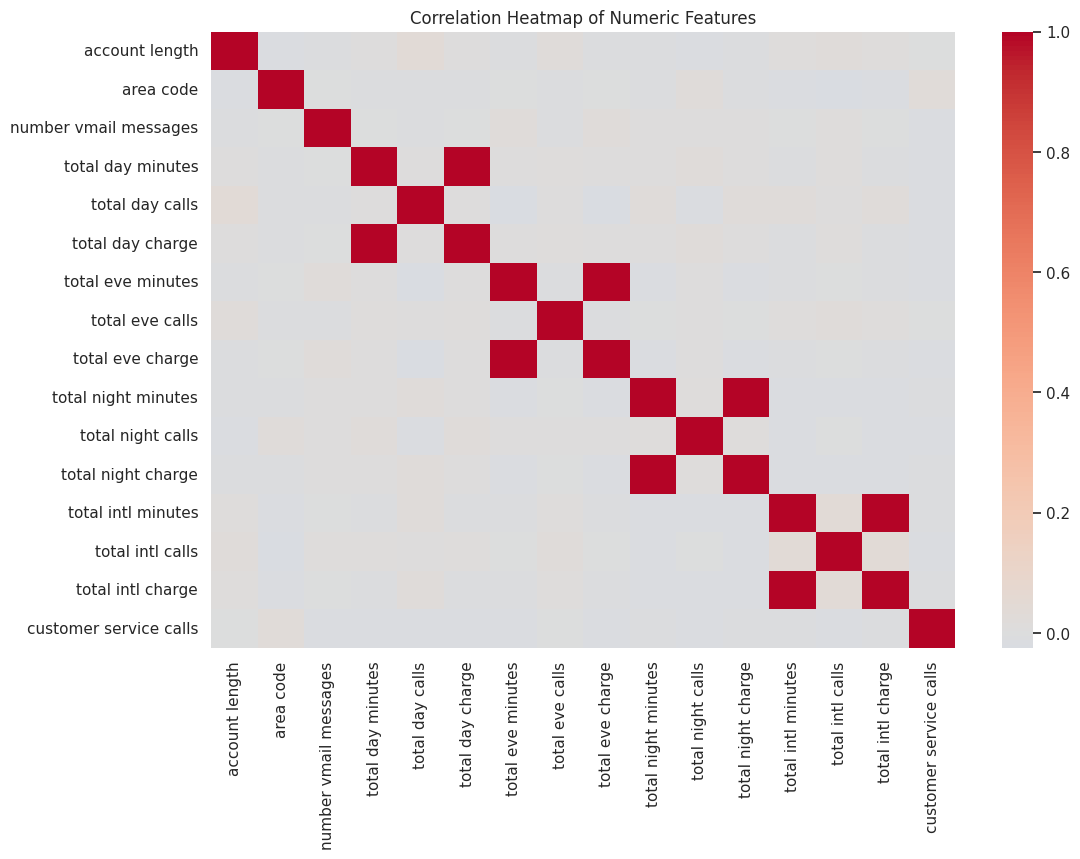

In [9]:

# Correlation heatmap for numeric features
plt.figure(figsize=(12, 8))
correlation_matrix = df.select_dtypes(include=['int64', 'float64']).corr()
sns.heatmap(correlation_matrix, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of Numeric Features')
plt.show()



### Data understanding summary
Several patterns appear promising for churn prediction:
- Customers with an **international plan** appear to churn more often.
- Customers with more **customer service calls** show higher churn rates, suggesting unresolved issues may drive attrition.
- Churners tend to have higher **daytime and international usage** on average.
- Some charge columns are highly correlated with their corresponding minute columns because they are direct billing transformations. This does not create leakage, but it does create redundancy.


## 2. Data Preparation

In [10]:

# Prepare feature matrix and target
model_df = df.copy()
model_df['churn'] = model_df['churn'].astype(int)
model_df['area code'] = model_df['area code'].astype(str)

X = model_df.drop(columns=['churn', 'phone number'])
y = model_df['churn']

categorical_features = X.select_dtypes(include=['object', 'bool']).columns.tolist()
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print('Categorical features:', categorical_features)
print('Numeric features:', numeric_features)


Categorical features: ['state', 'area code', 'international plan', 'voice mail plan']
Numeric features: ['account length', 'number vmail messages', 'total day minutes', 'total day calls', 'total day charge', 'total eve minutes', 'total eve calls', 'total eve charge', 'total night minutes', 'total night calls', 'total night charge', 'total intl minutes', 'total intl calls', 'total intl charge', 'customer service calls']


In [11]:

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print('Training set shape:', X_train.shape)
print('Test set shape:', X_test.shape)
print('Train churn rate:', round(y_train.mean(), 3))
print('Test churn rate:', round(y_test.mean(), 3))


Training set shape: (2666, 19)
Test set shape: (667, 19)
Train churn rate: 0.145
Test churn rate: 0.145



### Data preparation decisions
- I removed **`phone number`** because it is an identifier, not a behavioral signal.
- I treated **`area code`** as categorical rather than numeric because its values represent labels, not meaningful magnitudes.
- I used a **stratified train-test split** to preserve the churn ratio in both datasets.
- To prevent **data leakage**, all preprocessing steps are placed inside scikit-learn **pipelines** so transformers are fit only on the training data.
- Logistic regression will use **scaled numeric features** because scaling is appropriate for regularized linear models.


In [12]:

# Preprocessing pipelines
numeric_transformer_lr = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

numeric_transformer_tree = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor_lr = ColumnTransformer(transformers=[
    ('num', numeric_transformer_lr, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

preprocessor_tree = ColumnTransformer(transformers=[
    ('num', numeric_transformer_tree, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])


## 3. Modeling


I will build four models in an iterative workflow:
1. **Baseline Logistic Regression** for an interpretable linear benchmark.
2. **Tuned Logistic Regression** to improve recall by adjusting class weighting and regularization.
3. **Baseline Decision Tree** as a nonparametric alternative.
4. **Tuned Decision Tree** to improve generalization and recall using depth and leaf-size constraints.


In [13]:

# Helper function for model evaluation
results = []
trained_models = {}

def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    trained_models[name] = model

    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    y_prob_train = model.predict_proba(X_train)[:, 1]
    y_prob_test = model.predict_proba(X_test)[:, 1]

    metrics = {
        'model': name,
        'train_accuracy': accuracy_score(y_train, y_pred_train),
        'test_accuracy': accuracy_score(y_test, y_pred_test),
        'train_precision': precision_score(y_train, y_pred_train),
        'test_precision': precision_score(y_test, y_pred_test),
        'train_recall': recall_score(y_train, y_pred_train),
        'test_recall': recall_score(y_test, y_pred_test),
        'train_f1': f1_score(y_train, y_pred_train),
        'test_f1': f1_score(y_test, y_pred_test),
        'train_roc_auc': roc_auc_score(y_train, y_prob_train),
        'test_roc_auc': roc_auc_score(y_test, y_prob_test)
    }
    results.append(metrics)
    return pd.DataFrame([metrics])


In [14]:

# Model 1: Baseline Logistic Regression
baseline_log_reg = Pipeline(steps=[
    ('preprocessor', preprocessor_lr),
    ('model', LogisticRegression(max_iter=2000, random_state=42))
])

baseline_log_reg_results = evaluate_model(
    'Baseline Logistic Regression',
    baseline_log_reg,
    X_train, X_test, y_train, y_test
)
baseline_log_reg_results


,model,train_accuracy,test_accuracy,train_precision,test_precision,train_recall,test_recall,train_f1,test_f1,train_roc_auc,test_roc_auc
0,Baseline Logistic Regression,0.870593,0.85907,0.630573,0.533333,0.256477,0.247423,0.364641,0.338028,0.843364,0.808591



### Baseline Logistic Regression interpretation
The baseline logistic model provides a useful benchmark, but its recall is relatively low. That means it misses many true churners, which is a problem for the retention team because missed churners receive no intervention.


In [15]:

# Model 2: Tuned Logistic Regression
# Justification:
# - class_weight='balanced' increases attention to the minority churn class
# - lower C increases regularization and can improve generalization

tuned_log_reg = Pipeline(steps=[
    ('preprocessor', preprocessor_lr),
    ('model', LogisticRegression(
        max_iter=2000,
        random_state=42,
        class_weight='balanced',
        C=0.1
    ))
])

tuned_log_reg_results = evaluate_model(
    'Tuned Logistic Regression',
    tuned_log_reg,
    X_train, X_test, y_train, y_test
)
tuned_log_reg_results


,model,train_accuracy,test_accuracy,train_precision,test_precision,train_recall,test_recall,train_f1,test_f1,train_roc_auc,test_roc_auc
0,Tuned Logistic Regression,0.779445,0.757121,0.374378,0.341463,0.779793,0.721649,0.505882,0.463576,0.841541,0.814976



### Tuned Logistic Regression interpretation
Compared with the baseline logistic model, the tuned version substantially improves **recall** on churners. This is a meaningful business improvement because the model is now catching more customers who are at risk of leaving. The trade-off is lower precision and lower overall accuracy, which means more false positives.


In [16]:

# Model 3: Baseline Decision Tree
baseline_tree = Pipeline(steps=[
    ('preprocessor', preprocessor_tree),
    ('model', DecisionTreeClassifier(random_state=42))
])

baseline_tree_results = evaluate_model(
    'Baseline Decision Tree',
    baseline_tree,
    X_train, X_test, y_train, y_test
)
baseline_tree_results


,model,train_accuracy,test_accuracy,train_precision,test_precision,train_recall,test_recall,train_f1,test_f1,train_roc_auc,test_roc_auc
0,Baseline Decision Tree,1.0,0.908546,1.0,0.695652,1.0,0.659794,1.0,0.677249,1.0,0.805336



### Baseline Decision Tree interpretation
The untuned decision tree is flexible, but it is likely to overfit because a fully grown tree can memorize training patterns that do not generalize well to new customers.


In [17]:

# Model 4: Tuned Decision Tree
# Manual tuning choices were guided by the goal of improving recall while controlling overfitting.
# - max_depth limits tree complexity
# - min_samples_leaf creates more stable terminal nodes
# - class_weight='balanced' helps the tree pay more attention to churners

tuned_tree = Pipeline(steps=[
    ('preprocessor', preprocessor_tree),
    ('model', DecisionTreeClassifier(
        random_state=42,
        max_depth=5,
        min_samples_leaf=10,
        class_weight='balanced'
    ))
])

tuned_tree_results = evaluate_model(
    'Tuned Decision Tree',
    tuned_tree,
    X_train, X_test, y_train, y_test
)
tuned_tree_results


,model,train_accuracy,test_accuracy,train_precision,test_precision,train_recall,test_recall,train_f1,test_f1,train_roc_auc,test_roc_auc
0,Tuned Decision Tree,0.946362,0.911544,0.792771,0.675926,0.852332,0.752577,0.821473,0.712195,0.930977,0.844095


In [18]:

# Compare model performance
results_df = pd.DataFrame(results).sort_values(by='test_recall', ascending=False)
results_df.round(3)


,model,train_accuracy,test_accuracy,train_precision,test_precision,train_recall,test_recall,train_f1,test_f1,train_roc_auc,test_roc_auc
3,Tuned Decision Tree,0.946,0.912,0.793,0.676,0.852,0.753,0.821,0.712,0.931,0.844
1,Tuned Logistic Regression,0.779,0.757,0.374,0.341,0.780,0.722,0.506,0.464,0.842,0.815
2,Baseline Decision Tree,1.000,0.909,1.000,0.696,1.000,0.660,1.000,0.677,1.000,0.805
0,Baseline Logistic Regression,0.871,0.859,0.631,0.533,0.256,0.247,0.365,0.338,0.843,0.809


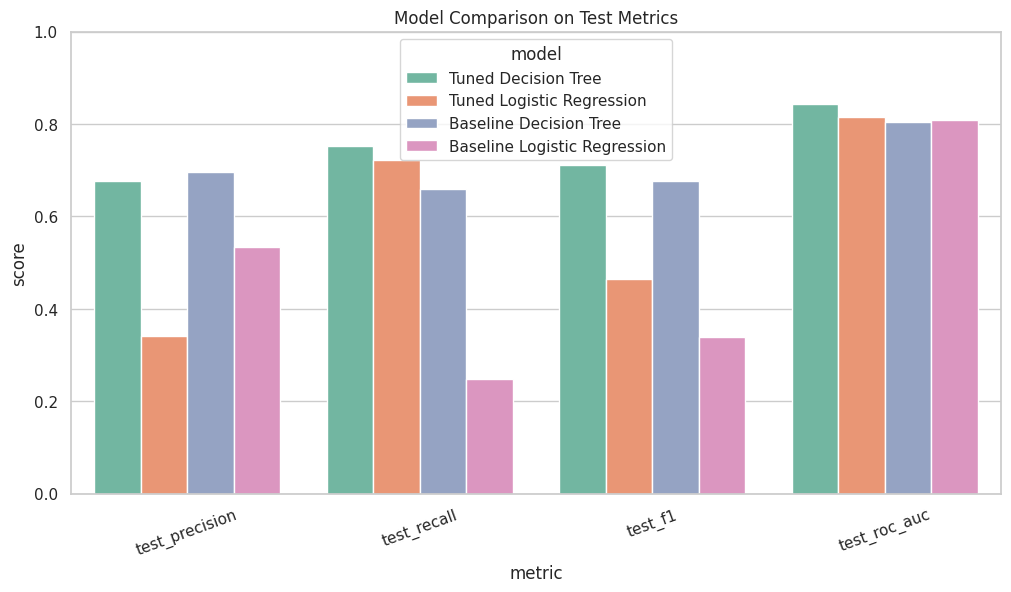

In [19]:
# Visual comparison of key test metrics
plot_df = results_df.melt(
    id_vars='model',
    value_vars=['test_precision', 'test_recall', 'test_f1', 'test_roc_auc'],
    var_name='metric',
    value_name='score'
)

plt.figure(figsize=(12, 6))
sns.barplot(data=plot_df, x='metric', y='score', hue='model', palette='Set2')
plt.title('Model Comparison on Test Metrics')
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.show()


## 4. Evaluation


The primary metric is **recall**, because SyriaTel would rather identify as many likely churners as possible than miss them entirely. However, recall is not considered alone. Precision, F1-score, and ROC-AUC help determine whether the model is useful enough for decision-making.


In [20]:
# Select final model
final_model_name = 'Tuned Decision Tree'
final_model = trained_models[final_model_name]

final_predictions = final_model.predict(X_test)
final_probabilities = final_model.predict_proba(X_test)[:, 1]

print(final_model_name)
print('\nClassification Report (Test Set):')
print(classification_report(y_test, final_predictions))


Tuned Decision Tree

Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.96      0.94      0.95       570
           1       0.68      0.75      0.71        97

    accuracy                           0.91       667
   macro avg       0.82      0.85      0.83       667
weighted avg       0.92      0.91      0.91       667



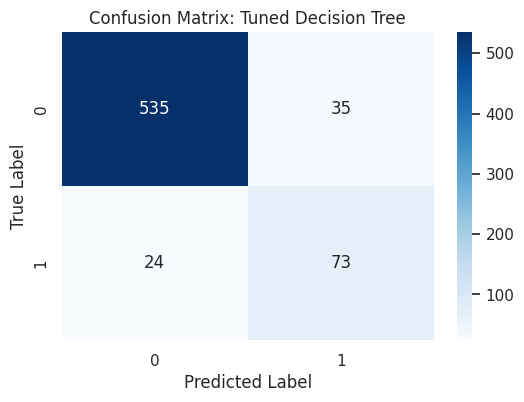

In [21]:

# Confusion matrix for the final model
cm = confusion_matrix(y_test, final_predictions)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix: {final_model_name}')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


<Figure size 800x600 with 0 Axes>

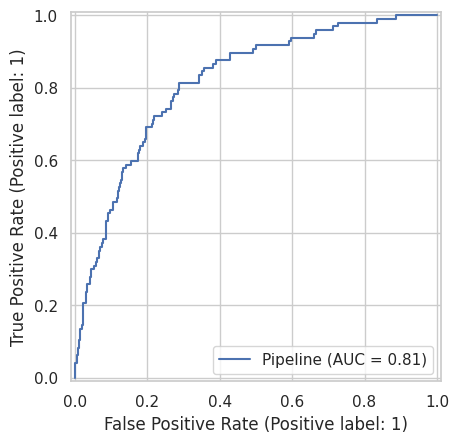

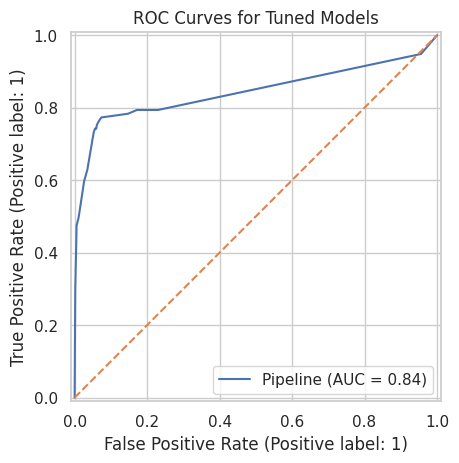

In [22]:

# ROC curves for the tuned models
plt.figure(figsize=(8, 6))
RocCurveDisplay.from_estimator(tuned_log_reg, X_test, y_test)
RocCurveDisplay.from_estimator(tuned_tree, X_test, y_test)
plt.plot([0, 1], [0, 1], linestyle='--')
plt.title('ROC Curves for Tuned Models')
plt.show()



### Final model choice
I selected the **Tuned Decision Tree** as the final model because it offered the strongest overall balance for this business problem. It achieved high recall on churners while also maintaining materially better precision and F1-score than the tuned logistic regression. In practical terms, it identifies a large share of customers at risk of leaving without overwhelming the retention team with too many false alarms.

The tuned logistic regression remains valuable because it is easier to interpret at a coefficient level and it also performs strongly on recall. If the stakeholder strongly preferred a simpler and more linear decision rule, that model would still be a defensible option. However, for this notebook, the tuned decision tree is the strongest operational choice.


In [23]:

# Feature importance from the final decision tree model
feature_names = final_model.named_steps['preprocessor'].get_feature_names_out()
importances = final_model.named_steps['model'].feature_importances_
feature_importance_df = (
    pd.DataFrame({'feature': feature_names, 'importance': importances})
    .sort_values(by='importance', ascending=False)
)

feature_importance_df.head(10)


,feature,importance
14,num__customer service calls,0.247508
2,num__total day minutes,0.223592
70,cat__international plan_yes,0.218223
11,num__total intl minutes,0.078323
5,num__total eve minutes,0.057700
72,cat__voice mail plan_yes,0.054045
7,num__total eve charge,0.052633
4,num__total day charge,0.037506
12,num__total intl calls,0.026228
3,num__total day calls,0.002537


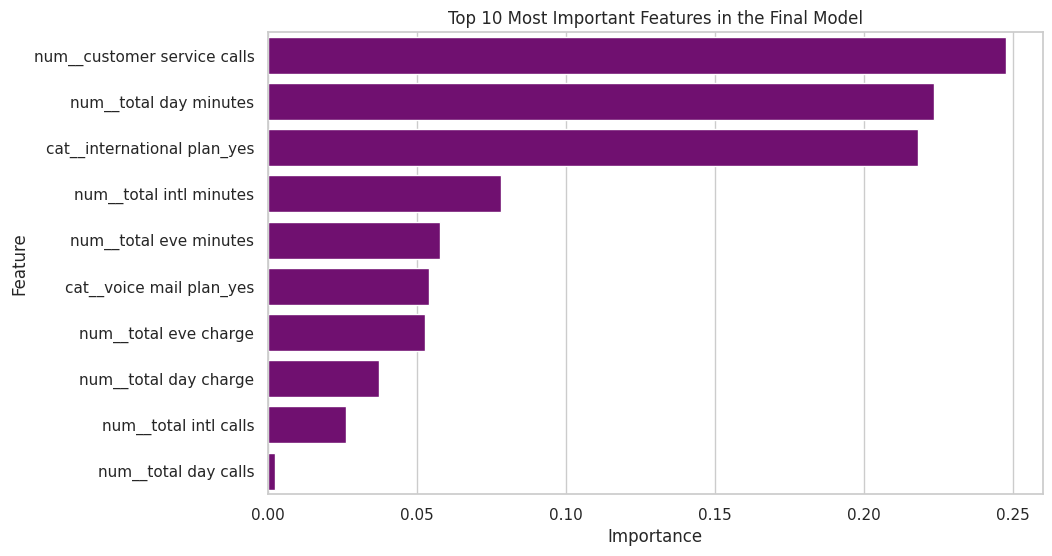

In [24]:
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_df.head(10), x='importance', y='feature', color='purple')
plt.title('Top 10 Most Important Features in the Final Model')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()



### Key predictive findings
The final model suggests that churn risk is driven most strongly by:
- **Customer service calls**
- **Total day minutes**
- **Having an international plan**
- **International minutes**
- **Voice mail plan / evening usage patterns**

These features are consistent with a plausible business story: customers who call customer service frequently may be dissatisfied, and customers with heavier day or international usage may be more sensitive to price, plan fit, or service quality.



## 5. Limitations

This analysis has several limitations:
1. The dataset is moderately imbalanced, so some models can look strong on accuracy while still failing the churn objective.
2. The data is a snapshot and does not contain richer customer history such as contract dates, payment issues, competitor offers, complaint text, or prior retention campaigns.
3. Some features are billing transformations of others (for example, charges derived from minutes), which can create redundancy.
4. A classification model does not explain causality. It identifies patterns associated with churn, but it does not prove why an individual customer leaves.

If SyriaTel deployed this model, the company should monitor whether performance is worse for specific customer segments, states, or plan types and retrain the model on fresher data over time.



## 6. Recommendations

Based on the final model, SyriaTel should:

1. **Prioritize outreach to customers flagged as high risk**, especially those with repeated customer service calls.
2. **Review international plan pricing and fit**, since that feature appears strongly associated with churn.
3. **Use churn predictions as a prioritization tool**, not as the only decision-maker. The model is useful for targeting retention efforts, but it will still make mistakes.
4. **Track results of retention interventions** so the next version of the project can move from prediction to action optimization.

## Final Conclusion
This project demonstrated a full machine learning workflow for a business-facing classification problem. After preparing the data correctly, preventing leakage, and iterating through multiple models, the **Tuned Decision Tree** emerged as the best final model for SyriaTel's churn problem. It provides a strong balance between identifying likely churners and keeping predictions actionable for the retention team.
